# What kills migrating birds in Chicago?

A walk through the analysis behind this repo. Every spring and fall, night-migrating
songbirds cross Chicago; some are drawn off course by lit high-rise windows and die
on the glass. Using 40 years of collision records from the Field Museum's monitoring
of **McCormick Place** and the surrounding city, we ask three questions:

1. **When** do collisions happen?
2. **Why** — what environmental factor drives them?
3. **Who** dies — which birds are most vulnerable?

The scripts (`etl.py`, `analyze.py`) are the reproducible pipeline; this notebook is
the narrative version.

## 1. Load the data

We reuse the project's own ETL so the notebook and the scripts can't drift apart: `etl.py` fetches the source files, cleans them, and joins each McCormick Place night to that night's building-light score.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from etl import collect, clean_collisions, build_mp_daily

collect()                       # fetch source files (cached after first run)
coll = clean_collisions()       # record-level, cleaned + typed
daily = build_mp_daily(coll)    # McCormick Place nights + light score

coll.head()

  cached   bird_collisions.csv
  cached   mp_light.csv
  cleaned  69,695 -> 69,695 collision records (0 dropped)
  merged   1,641 McCormick Place days with a light score


,genus,species,date,locality,family,flight_call,habitat,stratum,scientific_name,year,month,season,decade
0,Passerculus,sandwichensis,1978-10-27,McCormick Place,Passerellidae,Yes,Open,Lower,Passerculus sandwichensis,1978,10,Fall,1970
1,Passerculus,sandwichensis,1979-10-23,McCormick Place,Passerellidae,Yes,Open,Lower,Passerculus sandwichensis,1979,10,Fall,1970
2,Passerculus,sandwichensis,1980-04-19,McCormick Place,Passerellidae,Yes,Open,Lower,Passerculus sandwichensis,1980,4,Spring,1980
3,Passerculus,sandwichensis,1981-09-23,McCormick Place,Passerellidae,Yes,Open,Lower,Passerculus sandwichensis,1981,9,Fall,1980
4,Passerculus,sandwichensis,1982-05-20,McCormick Place,Passerellidae,Yes,Open,Lower,Passerculus sandwichensis,1982,5,Spring,1980


Two frames: `coll` is one row per collision (species, family, date, behaviour); `daily` is one row per McCormick Place night with its collision count and light score.

In [2]:
print("collision records:", f"{len(coll):,}")
print("years covered      :", int(coll.year.min()), "-", int(coll.year.max()))
print("MP nights w/ light :", f"{len(daily):,}")
coll[["family", "flight_call", "season"]].describe()

collision records: 69,695
years covered      : 1978 - 2016
MP nights w/ light : 1,641


,family,flight_call,season
count,69695,69695,69695
unique,15,3,2
top,Passerellidae,Yes,Fall
freq,34211,67026,44073


## 2. When? — collisions track the migration calendar

The records only span the spring (Mar–May) and fall (Aug–Nov) passage months, and within those, deaths pile up in fall — peaking in October.

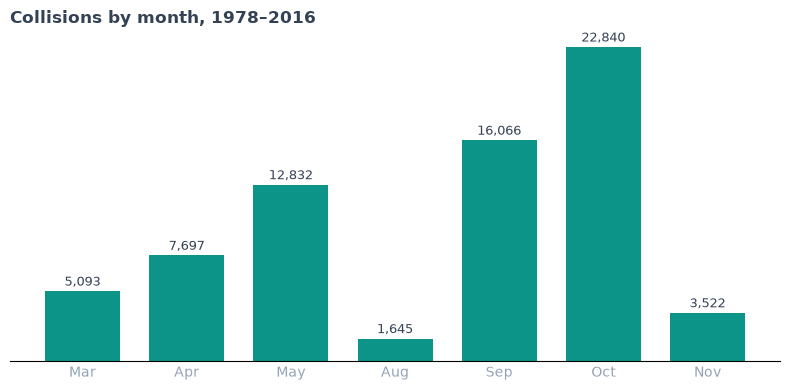

In [3]:
MONTHS = {3:"Mar",4:"Apr",5:"May",8:"Aug",9:"Sep",10:"Oct",11:"Nov"}
by_month = coll.month.value_counts().reindex(MONTHS).fillna(0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar([MONTHS[m] for m in by_month.index], by_month.values, color="#0d9488", width=0.72)
for x, v in enumerate(by_month.values):
    ax.text(x, v + 400, f"{int(v):,}", ha="center", fontsize=9, color="#334155")
ax.set_title("Collisions by month, 1978–2016", loc="left", fontweight="bold", color="#334155")
for s in ("top","right","left"): ax.spines[s].set_visible(False)
ax.set_yticks([]); ax.tick_params(length=0, colors="#94a3b8")
plt.tight_layout(); plt.show()

> **Finding.** Nearly every recorded death falls in a migration window, with a pronounced fall peak. Timing alone already tells conservationists *when* to act.

## 3. Why? — brighter nights kill more birds

`daily` pairs each McCormick Place night's death count with its building-light score. Do lit nights kill more? We bin nights into light terciles and compare.

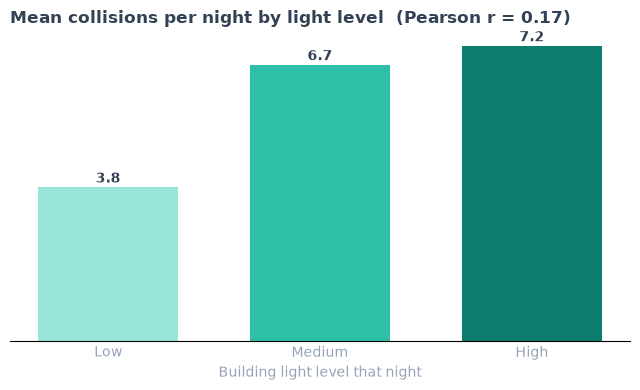

Pearson r  = 0.172
Spearman   = 0.191


In [4]:
r = daily.light_score.corr(daily.collisions)
daily = daily.assign(tercile=pd.qcut(daily.light_score, 3, labels=["Low","Medium","High"]))
means = daily.groupby("tercile", observed=True).collisions.mean()

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(means.index.astype(str), means.values, color=["#99e6d9","#2dbfa8","#0d7d6e"], width=0.66)
for x, v in enumerate(means.values):
    ax.text(x, v + 0.12, f"{v:.1f}", ha="center", fontweight="bold", color="#334155")
ax.set_title(f"Mean collisions per night by light level  (Pearson r = {r:.2f})",
             loc="left", fontweight="bold", color="#334155")
ax.set_xlabel("Building light level that night", color="#94a3b8")
for s in ("top","right","left"): ax.spines[s].set_visible(False)
ax.set_yticks([]); ax.tick_params(length=0, colors="#94a3b8")
plt.tight_layout(); plt.show()

print(f"Pearson r  = {r:.3f}")
print(f"Spearman   = {daily.light_score.rank().corr(daily.collisions.rank()):.3f}")

> **Finding.** Nights in the brightest third average roughly **twice** the deaths of the darkest third. The correlation is modest but robust across 1,600+ nights — and unlike weather or season, building light is something a city can *switch off*. This is the evidence base for **lights-out** programs.

## 4. Who? — one behaviour explains most of the toll

Birds that call in flight at night are thought to be disproportionately lured toward lit buildings. The data agree, overwhelmingly.

nocturnal flight-callers: 96.2% of all collisions


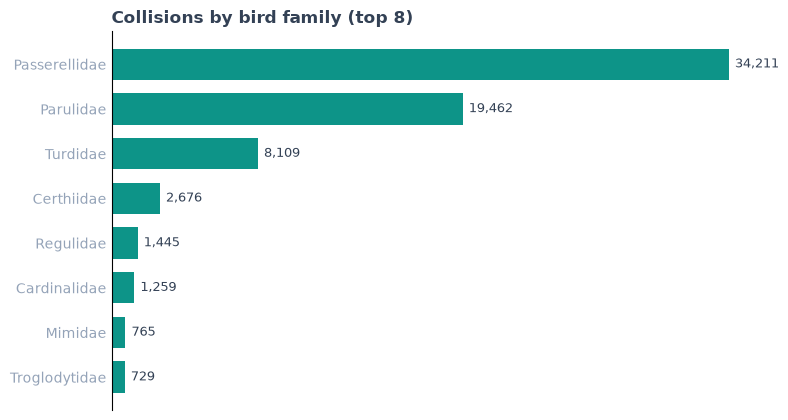

In [5]:
share = (coll.flight_call == "Yes").mean()
print(f"nocturnal flight-callers: {share:.1%} of all collisions")

top = coll.family.value_counts().head(8).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.barh(top.index, top.values, color="#0d9488", height=0.7)
for y, v in enumerate(top.values):
    ax.text(v + top.max()*0.01, y, f"{int(v):,}", va="center", fontsize=9, color="#334155")
ax.set_title("Collisions by bird family (top 8)", loc="left", fontweight="bold", color="#334155")
for s in ("top","right","bottom"): ax.spines[s].set_visible(False)
ax.set_xticks([]); ax.tick_params(length=0, colors="#94a3b8")
plt.tight_layout(); plt.show()

> **Finding.** **96%** of collisions are nocturnal flight-calling species, and a few migratory families — sparrows, warblers, thrushes — take most of the toll. Vulnerability is a trait, not bad luck.

## 5. How concentrated? — a few nights dominate

If deaths were spread evenly, the curve below would follow the diagonal. Instead it bows hard: a small fraction of nights carries most of the toll. (This is about the *shape* of the distribution, so unlike a year-over-year trend it isn't distorted by how monitoring effort changed over time.)

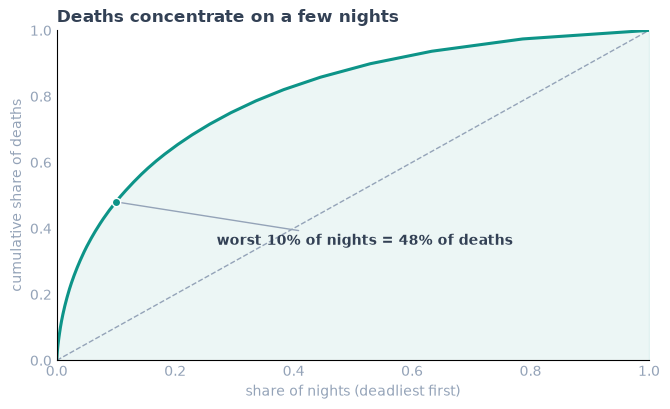

worst 1% of nights:  14% of deaths
worst 10% of nights: 48% of deaths
median night: 4 birds  |  worst night: 269


In [6]:
nights = (coll[coll.locality == "McCormick Place"].groupby("date").size()
          .sort_values(ascending=False).values)
cum = nights.cumsum() / nights.sum()
x = [(i + 1) / len(nights) for i in range(len(nights))]
i10 = int(len(nights) * 0.10); y10 = cum[i10 - 1]

fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.plot([0, 1], [0, 1], color="#94a3b8", ls="--", lw=1)
ax.fill_between([0] + x, [0] + list(cum), color="#0d9488", alpha=0.08)
ax.plot([0] + x, [0] + list(cum), color="#0d9488", lw=2.2)
ax.scatter([0.10], [y10], color="#0d9488", zorder=5, edgecolor="white")
ax.annotate(f"worst 10% of nights = {y10:.0%} of deaths", (0.10, y10),
            xytext=(0.27, y10 - 0.13), fontsize=10, color="#334155", fontweight="bold",
            arrowprops=dict(arrowstyle="-", color="#94a3b8"))
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("share of nights (deadliest first)", color="#94a3b8")
ax.set_ylabel("cumulative share of deaths", color="#94a3b8")
ax.set_title("Deaths concentrate on a few nights", loc="left", fontweight="bold", color="#334155")
for s in ("top", "right"): ax.spines[s].set_visible(False)
ax.tick_params(length=0, colors="#94a3b8")
plt.tight_layout(); plt.show()

print(f"worst 1% of nights:  {cum[int(len(nights)*0.01)-1]:.0%} of deaths")
print(f"worst 10% of nights: {y10:.0%} of deaths")
print(f"median night: {int(pd.Series(nights).median())} birds  |  worst night: {int(nights.max())}")

> **Finding.** The worst **10% of nights cause ~48%** of all deaths (the worst 1% alone, ~14%). A typical night kills 4 birds; the worst on record killed 269. So the intervention can be *targeted*: lights-out on the high-risk nights, not every night.

## Conclusion — a problem a city can turn off

The signals line up into one conservation story:

- **When:** deaths are concentrated in the spring and fall migration windows.
- **Why:** they rise with building light — the one driver under human control.
- **Who:** nocturnal flight-calling migrants are hit hardest.
- **How much:** and it all lands on a few nights — half the toll on a tenth of the nights.

Together they point to a cheap, high-leverage intervention: **lights-out on the
high-risk migration nights**, exactly the policy this kind of evidence has supported in
Chicago, New York, and Toronto. The full reproducible pipeline is in `etl.py` and `analyze.py`.